In [2]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle

In [ ]:
with open('parent_dictionary.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [ ]:
#Loading Data

In [6]:
fn ='Active_SAMap_Joined/active_samap/sm_Allen_Full_mo_soupxplus5_cleaned_03122025_subclass_250.pkl'

In [7]:
ref = 'mg'
org = 'mo'

In [8]:
sm = load_samap(fn)

finished mapping 6.666666666666667 percent in 15.250614881515503 seconds
finished mapping 13.333333333333334 percent in 31.027422666549683 seconds
finished mapping 20.0 percent in 47.390005588531494 seconds
finished mapping 26.666666666666668 percent in 63.93501353263855 seconds
finished mapping 33.333333333333336 percent in 81.80023670196533 seconds
finished mapping 40.0 percent in 100.22544717788696 seconds
finished mapping 46.66666666666667 percent in 119.3401288986206 seconds
finished mapping 53.333333333333336 percent in 138.32055139541626 seconds
finished mapping 60.0 percent in 158.55584406852722 seconds
finished mapping 66.66666666666667 percent in 179.308012008667 seconds
finished mapping 73.33333333333334 percent in 201.17593812942505 seconds
finished mapping 80.0 percent in 223.2373285293579 seconds
finished mapping 86.66666666666667 percent in 245.05606651306152 seconds
finished mapping 93.33333333333334 percent in 268.1267890930176 seconds
finished mapping 100.0 percent in

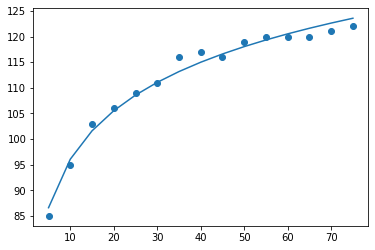

In [9]:
#Level of mapping
level = 'subclass_id_label'

t0 = time.time()
spline = []
num_cell_types = []

#range of leiden clustering resolutions 
for reso in range(5,80,5):
    sm.sams[org].clustering(param=reso)
    
    #get mapping between mouse and org
    keys = {ref:level,org:'leiden_clusters'}
    D,MappingTable = get_mapping_scores(sm,keys)
    lim_MappingTable = MappingTable.filter(like=org + '_')
    lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref)]
    
    #find the best mapping that has more than 25 cells and greater than .2 alignment score 
    mapping_dict = {}
    for item in lim_MappingTable:
        len_item = len(sm.sams[org].adata[sm.sams[org].adata.obs['leiden_clusters'] == int(item[3:])])
        if len_item > 25 and max(lim_MappingTable[item]) > .2:
            mapping_dict[item] = str(lim_MappingTable[item].idxmax())
        else:
            mapping_dict[item] = ref + '_Unlabeled'
    
    #saving the new mappings and leiden clusters
    new_mapping = []
    for item in sm.sams[org].adata.obs['leiden_clusters']:
        new_mapping.append(mapping_dict[org + '_' + str(item)][3:])
        
    sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)] = new_mapping
    sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(reso)] = sm.sams[org].adata.obs['leiden_clusters']
    num_cell_types.append(sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(reso)].nunique())
    t1 = time.time()
    print('finished mapping ' + str((reso/5)*(100/15)) + ' percent in ' + str(t1-t0) + ' seconds')

#get a function for the curve and plot to see how well it matches data
x = [i for i in range(5,80,5)]
func = np.polyfit(np.log(x), num_cell_types, 1)
plt.plot([i for i in range(5,80,5)], [func[0] * np.log(i) + func[1] for i in range(5,80,5)])
plt.scatter(x, num_cell_types)
plt.show()

In [10]:
func = np.polyfit(np.log(x), num_cell_types, 1)
a = func[0]
candidates = range(5, 80, 5)
best_reso = next((r for r in candidates
                  if a * np.log((r + 5) / r) < 1), None)
print(best_reso)

70


In [11]:
filtered_reso = filter(lambda x: x < func[0]*5, [i for i in range(5,80,5)])
best_reso = list(filtered_reso)[-1]
print(best_reso)

#remove the temporary mappings and keep the actual mapping
for i in range(5,80,5):
    print(i)
    if i != best_reso:
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_' + level + '_reso_' + str(i), axis = 1)
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_lc_reso_' + str(i), axis = 1)
    else:
        sm.sams[org].adata.obs[level + '_mapping'] = sm.sams[org].adata.obs['temp_mapping_' + level + '_reso_' + str(i)]
        sm.sams[org].adata.obs[level + '_lc'] = sm.sams[org].adata.obs['temp_mapping_lc_reso_' + str(i)]
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_' + level + '_reso_' + str(i), axis = 1)
        sm.sams[org].adata.obs = sm.sams[org].adata.obs.drop('temp_mapping_lc_reso_' + str(i), axis = 1)

65
5
10
15
20
25
30
35
40
45
50
55
60
65
70
75


In [12]:
sum(sm.sams[org].adata.obs['subclass_id_label_mapping'] == 'Unlabeled')

13657

In [13]:
sm.sams[ref].adata.obs

,cell_label,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,donor_sex,dataset_label,x,y,cluster_alias,class_id_label,supertype_id_label,subclass_id_label,leiden_clusters
min_name,,,,,,,,,,,,,,,,,,,,
ATGTGTGTCCGAAGAG-L8TX_180406_01_B01,ATGTGTGTCCGAAGAG-020_A01,ATGTGTGTCCGAAGAG,020_A01,L8TX_180406_01_B01,WMB-10Xv2-HPF,cell,NaN,10Xv2,RHP,Snap25-IRES2-Cre;Ai14-381293,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv2,23.589087,-2.926331,1,01 IT-ET Glut,0082 L2 IT PPP-APr Glut_3,018 L2 IT PPP-APr Glut,139
TACGGATGTAGCTGCC-L8TX_180406_01_D01,TACGGATGTAGCTGCC-021_A01,TACGGATGTAGCTGCC,021_A01,L8TX_180406_01_D01,WMB-10Xv2-HPF,cell,NaN,10Xv2,RHP,Snap25-IRES2-Cre;Ai14-381295,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,WMB-10Xv2,22.959314,-2.873364,1,01 IT-ET Glut,0082 L2 IT PPP-APr Glut_3,018 L2 IT PPP-APr Glut,139
ACCCACTAGACTTGAA-L8TX_180406_01_B02,ACCCACTAGACTTGAA-020_D01,ACCCACTAGACTTGAA,020_D01,L8TX_180406_01_B02,WMB-10Xv2-HPF,cell,NaN,10Xv2,RHP,Snap25-IRES2-Cre;Ai14-381293,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv2,23.188400,-3.180795,1,01 IT-ET Glut,0082 L2 IT PPP-APr Glut_3,018 L2 IT PPP-APr Glut,139
TTAGGACCAGGTCCAC-L8TX_180406_01_B01,TTAGGACCAGGTCCAC-020_A01,TTAGGACCAGGTCCAC,020_A01,L8TX_180406_01_B01,WMB-10Xv2-HPF,cell,NaN,10Xv2,RHP,Snap25-IRES2-Cre;Ai14-381293,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv2,23.103802,-3.081545,1,01 IT-ET Glut,0082 L2 IT PPP-APr Glut_3,018 L2 IT PPP-APr Glut,139
TTTACTGCAATACGCT-L8TX_180406_01_D01,TTTACTGCAATACGCT-021_A01,TTTACTGCAATACGCT,021_A01,L8TX_180406_01_D01,WMB-10Xv2-HPF,cell,NaN,10Xv2,RHP,Snap25-IRES2-Cre;Ai14-381295,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,WMB-10Xv2,23.196730,-3.130419,1,01 IT-ET Glut,0082 L2 IT PPP-APr Glut_3,018 L2 IT PPP-APr Glut,139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTACTGCAGCGTAGA-L8TX_200227_01_C11,TTTACTGCAGCGTAGA-228.1_C01,TTTACTGCAGCGTAGA,228.1_C01,L8TX_200227_01_C11,WMB-10Xv3-CB,cell,NaN,10Xv3,CB,Slc32a1-IRES-Cre;Ai14-510544,Slc32a1-IRES-Cre/wt;Ai14(RCL-tdT)/wt,F,WMB-10Xv3,-10.091989,-3.177620,4170,28 CB GABA,1151 CBX MLI Cdh22 Gaba_1,312 CBX MLI Cdh22 Gaba,35
TTTAGTCAGATCGACG-L8TX_191119_01_B11,TTTAGTCAGATCGACG-179_A01,TTTAGTCAGATCGACG,179_A01,L8TX_191119_01_B11,WMB-10Xv3-MY,cell,NaN,10Xv3,MY,Snap25-IRES2-Cre;Ai14-494813,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,WMB-10Xv3,-11.014988,-5.247750,5150,29 CB Glut,1154 CB Granule Glut_1,314 CB Granule Glut,121
TTTCGATGTAACCCTA-L8TX_200306_01_F12,TTTCGATGTAACCCTA-231.2_A01,TTTCGATGTAACCCTA,231.2_A01,L8TX_200306_01_F12,WMB-10Xv3-MY,cell,NaN,10Xv3,MY,Snap25-IRES2-Cre;Ai14-511242,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,WMB-10Xv3,-9.032933,-5.422258,5153,29 CB Glut,1156 DCO UBC Glut_1,315 DCO UBC Glut,127


In [19]:
sm.sams[org].adata.obs['supertype_id_label_mapping'].nunique()

255

In [18]:
sm.sams[org].adata.obs.to_csv('Active_SAMap_Joined/metadata_test/MO/MO_')

In [21]:
sm.sams[org].adata.obs['supertype_id_label_mapping'].to_csv('MO_supertype_v2_id_label_reduced_mapping_soupx.csv')

In [47]:
keys = {ref:level,org:'subclass_id_label_reduced_mapping'}
D,MappingTable = get_mapping_scores(sm,keys)
lim_MappingTable = MappingTable.filter(like=org + '_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(ref)]
lim_MappingTable.to_csv('Active_SAMap_Joined/' + level + '_v2_' + ref + '_' + org + '_heatmap_soupx.csv')

In [48]:
lim_MappingTable

,mo_007 L2/3 IT CTX Glut,mo_009 L2/3 IT PIR-ENTl Glut,mo_010 IT AON-TT-DP Glut,mo_013 COAp Grxcr2 Glut,mo_014 LA-BLA-BMA-PA Glut,mo_016 CA1-ProS Glut,mo_017 CA3 Glut,mo_037 DG Glut,mo_041 OB-in Frmd7 Gaba,mo_049 Lamp5 Gaba,...,mo_257 SPVC Ccdc172 Glut,mo_262 Pineal Crx Glut,mo_268 CS-PRNr-DR En1 Sox2 Gaba,mo_277 DTN-LDT-IPN Otp Pax3 Gaba,mo_294 MV Pax6 Gly-Gaba,mo_317 Astro NN,mo_326 OPC NN,mo_327 Oligo NN,mo_334 Microglia NN,mo_Unlabeled
mg_001 CLA-EPd-CTX Car3 Glut,0.000000,0.008042,0.026034,0.129375,0.005804,0.038583,0.033041,0.000424,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
mg_002 IT EP-CLA Glut,0.000599,0.000000,0.216754,0.262520,0.248482,0.002651,0.000908,0.022231,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000093,0.000716
mg_003 L5/6 IT TPE-ENT Glut,0.002187,0.002364,0.196263,0.103621,0.389912,0.001341,0.000000,0.024054,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000076,0.001070,0.001041
mg_004 L6 IT CTX Glut,0.003435,0.001727,0.196374,0.173694,0.316169,0.000000,0.000000,0.018914,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000107,0.000507,0.000470
mg_005 L5 IT CTX Glut,0.001119,0.021101,0.089263,0.068220,0.376535,0.000000,0.000000,0.005899,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000789,0.002486,0.004196
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mg_334 Microglia NN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.924188,0.001759
mg_335 BAM NN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.173636,0.000000
mg_336 Monocytes NN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.004110,0.0,0.0,0.0,0.0,0.0,0.000000,0.026723,0.005852
mg_337 DC NN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.0,0.000075,0.0,0.0,0.0,0.0,0.0,0.000000,0.024108,0.002496


In [53]:
#save new mapping 
with open(fn, 'wb') as f:
    dill.dump(sm, f, protocol = 4)

In [10]:
sm_decontx = load_samap('Active_SAMap_Joined/sm_Allen_full_mo.pkl')

In [14]:
sm_decontx.sams['mo'].adata.obs['subclass_id_label_mapping'].nunique()

115

In [21]:
sm.sams['mo'].adata.obs['subclass_id_label_mapping'].nunique()

119

In [15]:
hypo_set = set()
for item in sm.sams[org].adata.obs['subclass_id_label_mapping'].unique():
    if parent_dict[parent_dict[item]] == 'hypo':
        hypo_set.add(item)

In [16]:
len(hypo_set)

67

In [46]:
hypo_mapping = []
for item in sm.sams['mo'].adata.obs['subclass_id_label_mapping']:
    if item in hypo_set:
        hypo_mapping.append(item)
    else:
        hypo_mapping.append('Unlabeled')
sm.sams['mo'].adata.obs['subclass_id_label_mapping_hypo'] = hypo_mapping

In [47]:
hypo_set = set()
for item in sm_decontx.sams['mo'].adata.obs['subclass_id_label_mapping'].unique():
    if parent_dict[parent_dict[item]] == 'hypo':
        hypo_set.add(item)

In [48]:
hypo_mapping = []
for item in sm_decontx.sams['mo'].adata.obs['subclass_id_label_mapping']:
    if item in hypo_set:
        hypo_mapping.append(item)
    else:
        hypo_mapping.append('Unlabeled')
sm_decontx.sams['mo'].adata.obs['subclass_id_label_mapping_hypo'] = hypo_mapping

In [77]:
level = 'subclass_id_label_mapping_hypo'

In [78]:
ordered_genes = sm_decontx.sams[org].identify_marker_genes_ratio(level)

In [79]:
ordered_genes['Unlabeled']

array(['mo_ENSMOCG00000020936.1', 'mo_ENSMOCG00000010621.1',
       'mo_ENSMOCG00000014264.1', ..., 'mo_ENSMOCG00000005065.1',
       'mo_ENSMOCG00000017923.1', 'mo_ENSMOCG00000021712.1'], dtype='<U23')

In [80]:
#for marker dict vis (marker dict with threshold on fold change)
cta = np.zeros((len(ordered_genes) - 1, len(sm_decontx.sams[org].adata.var_names)))
fin_gene_order = []

gene_dict = {}
for i in range(len(sm_decontx.sams['mo'].adata.var_names)):
    gene_dict[sm_decontx.sams['mo'].adata.var_names[i]] = i 
    
#save celltype averaged exp
i = 0
for item in ordered_genes:
    if item != 'Unlabeled':
        cta[i,:] = np.average(sm_decontx.sams[org].adata[sm_decontx.sams[org].adata.obs[level] == item].X.A, axis = 0)
        i += 1
        for gene in ordered_genes[item][:30]:
            fin_gene_order.append(gene_dict[gene])
cta_sub = cta[:,fin_gene_order]
cta_sub_z = stats.zscore(cta_sub, axis = 0)

In [81]:
cta_sub_z.shape

(68, 2040)

Text(0.5, 82.5, 'Genes')

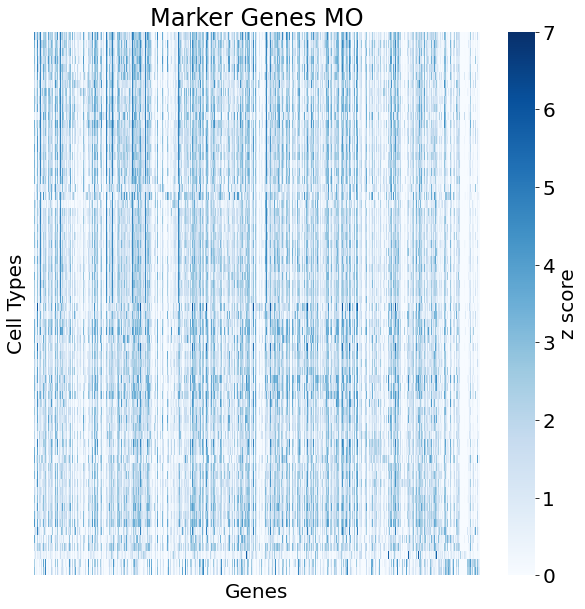

In [82]:
plt.figure(figsize=(10,10))
matplotlib.rcParams.update({'font.size': 20})
plt.title('Marker Genes ' + org.upper())
sns.heatmap(cta_sub, vmin = 0,vmax = 7, cmap = 'Blues', yticklabels = False,xticklabels = False,cbar_kws={'label': 'z score'})
plt.ylabel('Cell Types')
plt.xlabel('Genes')


In [83]:
ordered_genes = sm.sams[org].identify_marker_genes_ratio(level)

In [84]:
#for marker dict vis (marker dict with threshold on fold change)
cta = np.zeros((len(ordered_genes)-1, len(sm.sams[org].adata.var_names)))
fin_gene_order = []

gene_dict = {}
for i in range(len(sm.sams['mo'].adata.var_names)):
    gene_dict[sm.sams['mo'].adata.var_names[i]] = i 
    
#save celltype averaged exp
i = 0
for item in ordered_genes:
    if item != 'Unlabeled':
        cta[i,:] = np.average(sm.sams[org].adata[sm.sams[org].adata.obs[level] == item].X.A, axis = 0)
        i += 1
        for gene in ordered_genes[item][:30]:
            fin_gene_order.append(gene_dict[gene])
cta_sub = cta[:,fin_gene_order]
cta_sub_z = stats.zscore(cta_sub, axis = 0)

Text(0.5, 82.5, 'Genes')

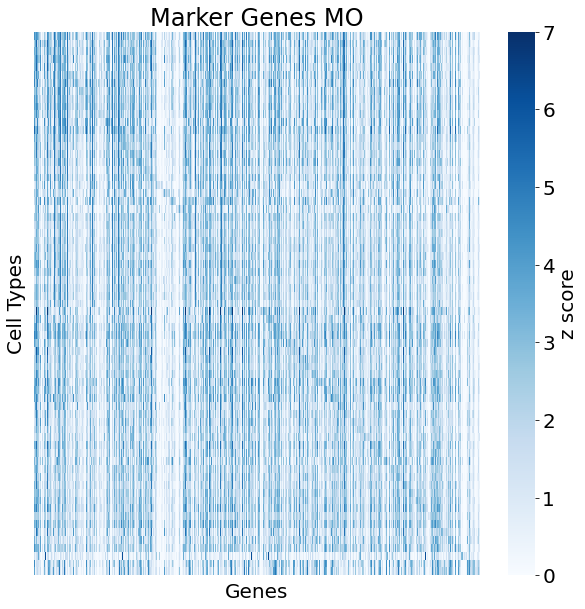

In [86]:
plt.figure(figsize=(10,10))
matplotlib.rcParams.update({'font.size': 20})
plt.title('Marker Genes ' + 'mo'.upper())
sns.heatmap(cta_sub, vmin = 0,vmax = 7, cmap = 'Blues', yticklabels = False,xticklabels = False,cbar_kws={'label': 'z score'})
plt.ylabel('Cell Types')
plt.xlabel('Genes')